# Modelling of peptide dataset and derived features

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
#Load in dataset with extra features added
peptide_df = pd.read_csv('data/peptides_modelling_df.csv')
peptide_df.head()

,ID,PeptideSequence,Modifications,RetentionTime,oxidation_count,acetyl_count,peptide_length,mean_hydrophobicity,mean_sasa,n_terminal,c_terminal,modification_present
0,66442,EELNAISGPNEFAEFYDR,NaN,76.808103,0.0,0.0,18,-0.067222,1.748833,E,R,False
1,9346,VPAQSESVR,NaN,-35.365414,0.0,0.0,9,-0.175556,1.654333,V,R,False
2,87137,SEPEDPVTER,NaN,-12.258285,0.0,0.0,10,-0.456000,1.713700,S,R,False
3,31419,SIRPGLSPYR,NaN,-0.953151,0.0,0.0,10,-0.200000,1.764200,S,R,False
4,93265,NLINEMLTINPAK,NaN,88.572770,0.0,0.0,13,0.125385,1.751923,N,K,False


In [3]:
def run_pipeline(df, num_cols, cat_cols, target_col):

    #Split data into train and test
    X = df[num_cols + cat_cols] 
    
    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


    #Make column transformer
    num_preproc = Pipeline(
        steps = [
            ('imputation_mean', SimpleImputer(strategy='median')), 
            ('scaler', StandardScaler()),
        ]
    )
    
    cat_preproc = Pipeline(
        steps = [
            ('imputation_const', SimpleImputer(strategy='constant', fill_value='UnKnown')), #Any NA gets its own category
            ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist', sparse_output=False))
        ]
    )
    
    preproc = ColumnTransformer(
        [
            ('categorical', cat_preproc, cat_cols),
            ('numerical', num_preproc, num_cols)
        ]
    )

    models = {
        'Linear_regression': LinearRegression(),
        'Ridge': Ridge(),
        'RandomForest': RandomForestRegressor(),
        'XGBoost': XGBRegressor()
    }
    
    results = {}
    
    for name, model in models.items():
        pipeline = Pipeline(
            steps=[
                ('preproc', preproc),
                ('model', model)
            ]
        )

        #Fit the model
        pipeline.fit(X_train, y_train) 

        #Predict for test set
        y_pred = pipeline.predict(X_test) 

        #Evaluate model performance
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
        results[name] = {'r2': r2, 'rmse':rmse, 'predictions':y_pred, 'model':pipeline}
        print(f'{name}: R2 = {r2:.3f}, RMSE = {rmse:.3f}') 
    
    #For each model plot predicted vs actual retention time
    fig, axes = plt.subplots(1, len(models), figsize = (15,4)) 
    
    for ax, (name, result) in zip(axes, results.items()):
        ax.scatter(y_test, result['predictions'])
        ax.set_title(f'{name} (R2 = {result["r2"]:.3f})')
        ax.set_xlabel('Actual Retention Time')
        ax.set_ylabel('Predicted Retention Time')

    return results

# Modeling run 1: Derived features

Linear_regression: R2 = 0.719, RMSE = 24.938
Ridge: R2 = 0.719, RMSE = 24.927
RandomForest: R2 = 0.734, RMSE = 24.289
XGBoost: R2 = 0.748, RMSE = 23.613


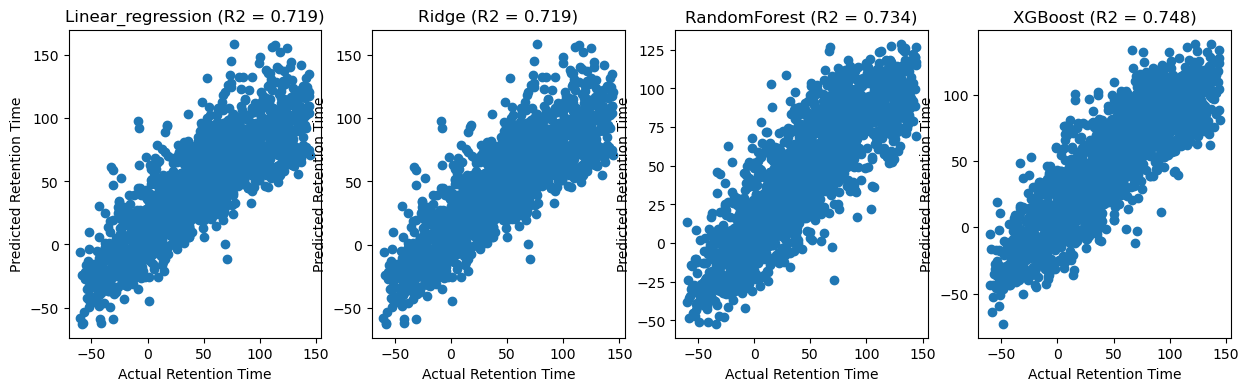

In [4]:
cat_cols = ['n_terminal', 'c_terminal']
num_cols = ['peptide_length', 'mean_hydrophobicity', 'mean_sasa', 'oxidation_count', 'acetyl_count']

results = run_pipeline(peptide_df, num_cols, cat_cols, 'RetentionTime')

# Modeling run 2: Use actual amino acid sequence as features

In [5]:
aa_list = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S','T', 'V', 'W', 'Y']

sequence_counts = []
for seq in peptide_df['PeptideSequence']:
    counts = {}
    for aa in aa_list:
        counts[aa] = seq.count(aa)
    sequence_counts.append(counts)

In [6]:
aa_count_df = pd.DataFrame(sequence_counts, index = peptide_df.index)
aa_count_df['RetentionTime'] = peptide_df['RetentionTime']
aa_count_df

,A,C,D,E,F,G,H,I,K,L,...,N,P,Q,R,S,T,V,W,Y,RetentionTime
0,2,0,1,4,2,1,0,1,0,1,...,2,1,0,1,1,0,0,0,1,76.808103
1,1,0,0,1,0,0,0,0,0,0,...,0,1,1,1,2,0,2,0,0,-35.365414
2,0,0,1,3,0,0,0,0,0,0,...,0,2,0,1,1,1,1,0,0,-12.258285
3,0,0,0,0,0,1,0,1,0,1,...,0,2,0,2,2,0,0,0,1,-0.953151
4,1,0,0,1,0,0,0,2,1,2,...,3,1,0,0,0,1,0,0,0,88.572770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,1,0,2,0,0,0,1,0,2,...,1,0,0,1,2,0,0,0,0,18.683235
9996,1,0,2,0,1,2,1,3,1,0,...,0,1,0,1,0,1,2,0,0,80.462639
9997,0,0,1,1,0,0,0,0,1,3,...,1,1,3,1,1,1,1,0,1,24.938680
9998,0,0,2,0,1,0,1,1,0,2,...,0,3,0,1,1,0,1,0,0,57.474966


Linear_regression: R2 = 0.854, RMSE = 18.000
Ridge: R2 = 0.854, RMSE = 18.000
RandomForest: R2 = 0.829, RMSE = 19.461
XGBoost: R2 = 0.880, RMSE = 16.314


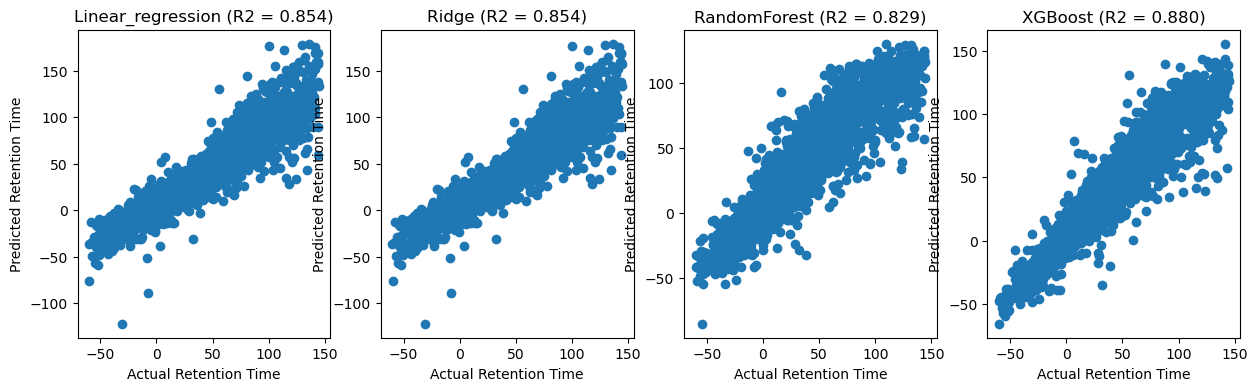

In [7]:
results = run_pipeline(aa_count_df, num_cols=aa_list, cat_cols=[], target_col='RetentionTime')

Switching to raw amino acid counts improves all models substantially (0.75 R2 to 0.88 R2 for XGBoost). Suggests that which amino acids are present matters more than the aggregate properties. Linear models peform similar to XGBoost here, suggesting the relationship between amino acid composition and retention time is largely linear 

# Modeling run 3: Use both derived features and amino acid counts

In [8]:
full_df = pd.concat([peptide_df, aa_count_df.drop(['RetentionTime'], axis = 1)], axis=1)
full_df

,ID,PeptideSequence,Modifications,RetentionTime,oxidation_count,acetyl_count,peptide_length,mean_hydrophobicity,mean_sasa,n_terminal,...,M,N,P,Q,R,S,T,V,W,Y
0,66442,EELNAISGPNEFAEFYDR,NaN,76.808103,0.0,0.0,18,-0.067222,1.748833,E,...,0,2,1,0,1,1,0,0,0,1
1,9346,VPAQSESVR,NaN,-35.365414,0.0,0.0,9,-0.175556,1.654333,V,...,0,0,1,1,1,2,0,2,0,0
2,87137,SEPEDPVTER,NaN,-12.258285,0.0,0.0,10,-0.456000,1.713700,S,...,0,0,2,0,1,1,1,1,0,0
3,31419,SIRPGLSPYR,NaN,-0.953151,0.0,0.0,10,-0.200000,1.764200,S,...,0,0,2,0,2,2,0,0,0,1
4,93265,NLINEMLTINPAK,NaN,88.572770,0.0,0.0,13,0.125385,1.751923,N,...,1,3,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,43305,LCNSLEESIR,NaN,18.683235,0.0,0.0,10,-0.136000,1.766800,L,...,0,1,0,0,1,2,0,0,0,0
9996,17792,RPFGVAVMDITDIIHGK,NaN,80.462639,0.0,0.0,17,0.208824,1.702059,R,...,1,0,1,0,1,0,1,2,0,0
9997,16249,LRPQTYDLQESNVQLK,NaN,24.938680,0.0,0.0,16,-0.286875,1.863438,L,...,0,1,1,3,1,1,1,1,0,1
9998,101011,LPPVLSHPIFDDR,NaN,57.474966,0.0,0.0,13,0.093846,1.769692,L,...,0,0,3,0,1,1,0,1,0,0


Linear_regression: R2 = 0.897, RMSE = 15.106
Ridge: R2 = 0.897, RMSE = 15.102
RandomForest: R2 = 0.859, RMSE = 17.658
XGBoost: R2 = 0.908, RMSE = 14.269


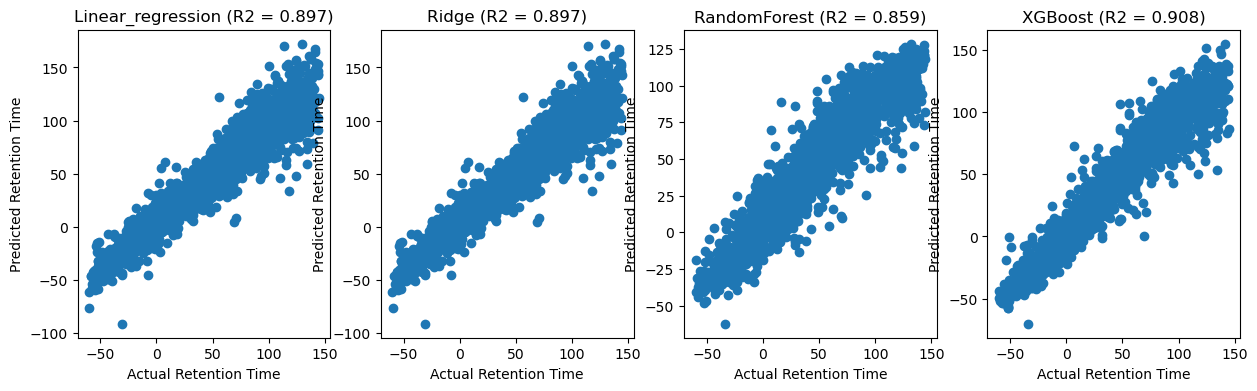

In [9]:
full_num_cols = num_cols + aa_list

results = run_pipeline(full_df, num_cols=full_num_cols, cat_cols=cat_cols, target_col='RetentionTime') 

Combining both sets of features gives the best results across all models, confirming that the engineered features and the amino acid counts carry complementary information. The engineered features capture global peptide properties while the counts capture specific residue-level contributions

In [10]:
#Feature importance from XGBoost model
xgb_pipeline = results['XGBoost']['model']
preproc_step = xgb_pipeline.named_steps['preproc']
xgb_model = xgb_pipeline.named_steps['model']

feature_names = preproc_step.get_feature_names_out()
importance_df = pd.DataFrame({
    'Feature' : feature_names,
    'Importance' : xgb_model.feature_importances_
}).sort_values('Importance', ascending = False)
importance_df

,Feature,Importance
52,numerical__L,0.213643
47,numerical__F,0.126894
38,numerical__peptide_length,0.086612
39,numerical__mean_hydrophobicity,0.070859
49,numerical__H,0.070028
...,...,...
26,categorical__c_terminal_I,0.000000
34,categorical__c_terminal_S,0.000000
31,categorical__c_terminal_P,0.000000
36,categorical__c_terminal_V,0.000000


The most important features are Leucine and Phenylalanine counts, both highly hydrophobic amino acids - Consistent with the known mechanism of hydrophobicity driving retention. Peptide length and mean hydrophobicity are also important alongside the raw counts confirming they carry complementary information.

Linear regression and ridge models produce identical R2 values, suggesting that there is no meaningful overfitting in linear model and regularisation is adding nothing, likely because the dataset is large enough for this number of features

**What I would do next**

**Positional effects of modifications** - The current approach looks at how many oxidations/acetylations a peptide has but not where they occur. Extension could be to encode modification position as a fraction of peptide length. 

**Hyperparamater tuning and cross validation** - All models use default parameters, tuning XGBoost in particular (learning rate, max depth, n estimators) would likely improve performance further. Best way to implement would be through K fold cross validation. 

**Residual analysis** - Identify which peptides the model predicts poorly and explore whether they share common properties 

**Sequence order** - The current models treat amino acids as just groups with no positional information. Natural extension would be to look at pairs or triplets of consecutive amino acids. Could also look at where in the sequence key amino acids appear. The final option would be a sequence model like a recurrent neural network or a transformer based model that can learn positional and contextual patterns directly. 